## Hashtag Toxicity Analyses For Twitter Archive and TruthSocial Datasets

In [ ]:

from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import statistics
import json

import tqdm

In [ ]:
from smdt.store.standard_db import StandardDB
import duckdb

db_name_truthsocial = "TruthSocial"
db_truthsocial = StandardDB(db_name=db_name_truthsocial, initialize=False)
conn_truthsocial = db_truthsocial.connect()
cursor_truthsocial = conn_truthsocial.cursor()

db_name_twitter = "ArchiverTwitterV1"
db_twitter = StandardDB(db_name=db_name_twitter, initialize=False)
conn_twitter = db_twitter.connect()
cursor_twitter = conn_twitter.cursor()

In [ ]:
# Get unique lowercase hashtags from TruthSocial 
cursor_truthsocial.execute("""
    SELECT DISTINCT LOWER(body) AS hashtag
    FROM entities
    WHERE entity_type = 'HASHTAG' AND body IS NOT NULL
""")
hashtags_1 = {row[0] for row in cursor_truthsocial.fetchall()}


# Get unique lowercase hashtags from Twitter Archive
cursor_twitter.execute("""
    SELECT DISTINCT LOWER(body) AS hashtag
    FROM entities
    WHERE entity_type = 'HASHTAG' AND body IS NOT NULL
""")
hashtags_2 = {row[0] for row in cursor_twitter.fetchall()}

# Intersected hashtags
shared_hashtags = hashtags_1 & hashtags_2

print(f"Shared hashtags ({len(shared_hashtags)}):", list(shared_hashtags)[:5])

# Get post_ids from both tables with those hashtags

cursor_truthsocial.execute("""
    SELECT LOWER(body) AS hashtag, post_id
    FROM entities
    WHERE entity_type = 'HASHTAG' AND body IS NOT NULL
""")
post_ids_1 = [(hashtag, post_id) for hashtag, post_id in cursor_truthsocial.fetchall() if hashtag in shared_hashtags]


cursor_twitter.execute("""
    SELECT LOWER(body) AS hashtag, post_id
    FROM entities
    WHERE entity_type = 'HASHTAG' AND body IS NOT NULL
""")
post_ids_2 = [(hashtag, post_id) for hashtag, post_id in cursor_twitter.fetchall() if hashtag in shared_hashtags]

print(f"First DB: {len(post_ids_1)} posts with shared hashtags")
print(f"Second DB: {len(post_ids_2)} posts with shared hashtags")

('1488986019064160259', 'NSD22')
('1489025567315877894', 'nooganature')
('1489025567315877894', 'jobs')
('1489025571502030849', 'PokemonLEGENDS発売')
('1489025571502030849', 'LegendsArceusSpoilers')
('1489002434227806217', 'PokemonLEGENDS発売')
('1489025571502030849', 'PokemonLegendsArceus')
('1489002434227806217', 'PokemonLegendsArceus')
('1488571130264711169', 'blackhistorymonth')
('1489025571518664706', 'blackhistorymonth')


In [ ]:
# Get unique lowercase hashtags from TruthSocial 
query = """
    SELECT DISTINCT LOWER(body) AS hashtag
    FROM entities
    WHERE entity_type = 'HASHTAG' AND body IS NOT NULL
"""
hashtags_1 = {row[0] for row in cursor_truthsocial.execute(query).fetchall()}


# Get unique lowercase hashtags from Twitter Archive
query = """
    SELECT DISTINCT LOWER(body) AS hashtag
    FROM entities
    WHERE entity_type = 'HASHTAG' AND body IS NOT NULL
"""
hashtags_2 = {row[0] for row in cursor_twitter.execute(query).fetchall()}

# Intersected hashtags
shared_hashtags = hashtags_1 & hashtags_2

print(f"Shared hashtags ({len(shared_hashtags)}):", list(shared_hashtags)[:5])

# Get post_ids from both tables with those hashtags

query = """
    SELECT LOWER(body) AS hashtag, post_id
    FROM entities
    WHERE entity_type = 'HASHTAG' AND body IS NOT NULL
"""
post_ids_1 = [(hashtag, post_id) for hashtag, post_id in cursor_truthsocial.execute(query).fetchall() if hashtag in shared_hashtags]


query = """
    SELECT LOWER(body) AS hashtag, post_id
    FROM entities
    WHERE entity_type = 'HASHTAG' AND body IS NOT NULL
"""
post_ids_2 = [(hashtag, post_id) for hashtag, post_id in cursor_twitter.execute(query).fetchall() if hashtag in shared_hashtags]

print(f"First DB: {len(post_ids_1)} posts with shared hashtags")
print(f"Second DB: {len(post_ids_2)} posts with shared hashtags")

Shared hashtags (10575): ['anthonyfauci', 'serpent', 'teachers', 'twtr', 'vets']
First DB: 140192 posts with shared hashtags
Second DB: 16604898 posts with shared hashtags


In [ ]:
# save post_ids to files

with open("truthsocial_shared_hashtags.txt", "w") as f:
    for hashtag, post_id in post_ids_1:
        f.write(f"{hashtag}\t{post_id}\n")

with open("twitter_archive_shared_hashtags.txt", "w") as f:
    for hashtag, post_id in post_ids_2:
        f.write(f"{hashtag}\t{post_id}\n")


In [ ]:
# load post_ids from files
truthsocial_post_ids = defaultdict(list)
with open("truthsocial_shared_hashtags.txt", "r") as f:
    for line in f:
        hashtag, post_id = line.strip().split("\t")
        truthsocial_post_ids[hashtag].append(post_id)

twitter_archive_post_ids = defaultdict(list)
with open("twitter_archive_shared_hashtags.txt", "r") as f:
    for line in f:
        hashtag, post_id = line.strip().split("\t")
        twitter_archive_post_ids[hashtag].append(post_id)


In [ ]:
def build_hashtag_postid_map(pairs):
    hashtag2posts = defaultdict(list)
    for hashtag, post_id in pairs.items():
        hashtag2posts[hashtag].append(post_id)
    return hashtag2posts

In [ ]:
from collections import defaultdict
import statistics
import json
import duckdb
import tqdm

db_name_truthsocial = "TruthSocial"
db_name_twitter = "ArchiverTwitterV1"

# load post_ids from files
hashtag2posts_truthSocial = defaultdict(list)
with open("truthsocial_shared_hashtags.txt", "r") as f:
    for line in f:
        hashtag, post_id = line.strip().split("\t")
        hashtag2posts_truthSocial[hashtag].append(post_id)

hashtag2posts_twitterArchive = defaultdict(list)
with open("twitter_archive_shared_hashtags.txt", "r") as f:
    for line in f:
        hashtag, post_id = line.strip().split("\t")
        hashtag2posts_twitterArchive[hashtag].append(post_id)
        

def collect_toxicity_by_hashtag_duckdb(db_name, post_ids_by_hashtag):
    hashtag2scores = defaultdict(list)

    all_post_ids = list(
        {post_id for post_ids in post_ids_by_hashtag.values() for post_id in post_ids}
    )

    postid2tox = {}
    file_path = f"/chistera/CaseStudyOutputs/HashtagDomain/detoxify_outputs/{db_name}/*.jsonl"

    print(f"Querying {file_path} via DuckDB...")
    try:

        query = f"""
            SELECT 
                post_id,
                (body->>'toxicity')::DOUBLE AS toxicity
            FROM read_json_auto('{file_path}')
            WHERE body->>'toxicity' IS NOT NULL
        """
        results = duckdb.query(query).df()
        postid2tox = dict(zip(results['post_id'].astype(str), results['toxicity']))

    except Exception as e:
        print(f"Error querying duckdb for {db_name}: {e}")

    # Group toxicity scores by hashtag
    for hashtag, post_ids in post_ids_by_hashtag.items():
        for pid in post_ids:
            if pid in postid2tox:
                hashtag2scores[hashtag].append(postid2tox[pid])

    return hashtag2scores

# Compute mean and std
def summarize_scores(tox_map):
    summary = {}
    for hashtag, scores in tox_map.items():
        if len(scores) >= 2:
            summary[hashtag] = {
                "mean": statistics.mean(scores),
                "std": statistics.stdev(scores),
                "count": len(scores),
                "scores": scores,
            }
        elif scores:
            summary[hashtag] = {"mean": scores[0], "std": 0.0, "count": 1, "scores": scores}
    return summary


tox_by_hashtag_truthSocial = collect_toxicity_by_hashtag_duckdb(
    db_name_truthsocial, hashtag2posts_truthSocial
)
summary_hashtag_toxicity_truthSocial = summarize_scores(tox_by_hashtag_truthSocial)

with open("toxicity_summary_truthsocial.json", "w") as f:
    json.dump(summary_hashtag_toxicity_truthSocial, f, indent=4)


tox_by_hashtag_twitter_archive = collect_toxicity_by_hashtag_duckdb(
    db_name_twitter, hashtag2posts_twitterArchive
)
summary_hashtag_toxicity_twitterArchive = summarize_scores(
    tox_by_hashtag_twitter_archive
)
with open("toxicity_summary_twitter_archive.json", "w") as f:
    json.dump(summary_hashtag_toxicity_twitterArchive, f, indent=4)

In [ ]:
# load results

import json
with open("toxicity_summary_truthsocial.json", "r") as f:
    summary_hashtag_toxicity_truthSocial = json.load(f)
with open("toxicity_summary_twitter_archive.json", "r") as f:
    summary_hashtag_toxicity_twitterArchive = json.load(f)

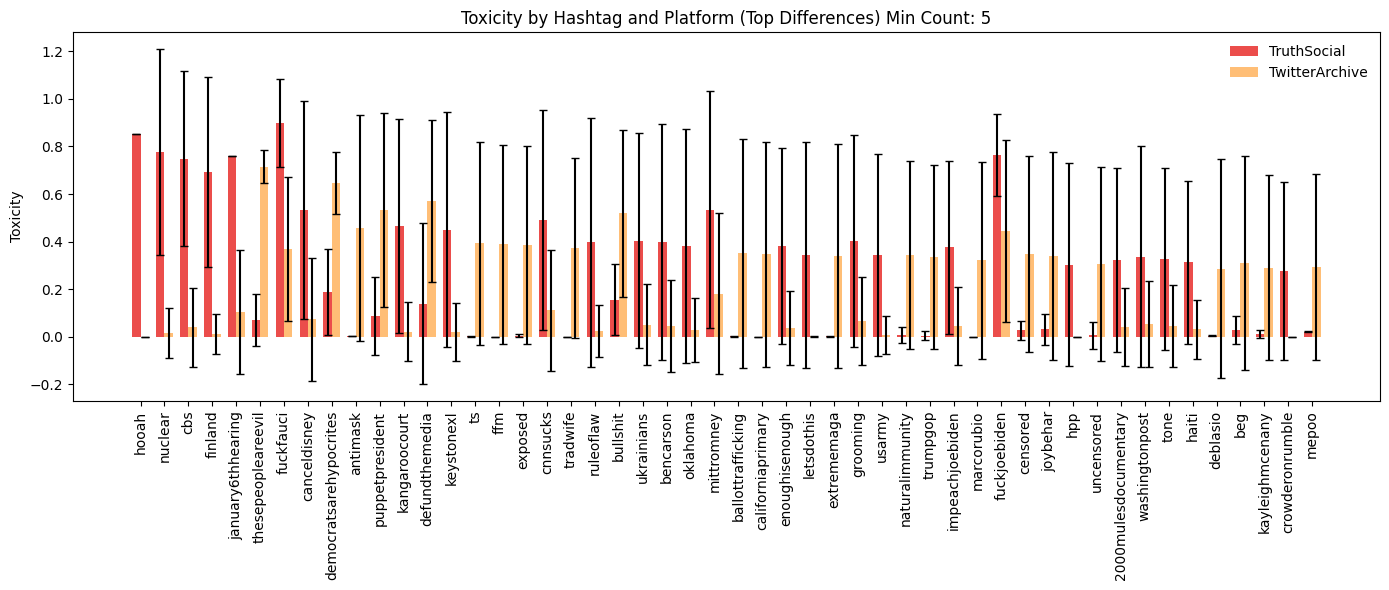

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

MIN_COUNT = 5  # Minimum number of posts to consider a hashtag
top_n = 50  # Number of top hashtags to visualize


# Find common hashtags
common_hashtags = set(summary_hashtag_toxicity_truthSocial) & set(summary_hashtag_toxicity_twitterArchive)

# Compute difference
hashtag_diffs = []
for h in common_hashtags:
    d1 = summary_hashtag_toxicity_truthSocial[h]
    d2 = summary_hashtag_toxicity_twitterArchive[h]
    
    if d1['count'] >= MIN_COUNT and d2['count'] >= MIN_COUNT:
        diff = abs(d1['mean'] - d2['mean'])
        hashtag_diffs.append((h, diff, d1['mean'], d2['mean'], d1['std'], d2['std']))

# Sort and pick top N
top_diff_hashtags = sorted(hashtag_diffs, key=lambda x: x[1], reverse=True)[:top_n]

# Unpack for plotting
hashtags = [h[0] for h in top_diff_hashtags]
# Sample data (replace with your actual data)
# hashtags = list(summary_hashtag_toxicity_truthSocial.keys())[:10]  # choose top N
truth_means = [summary_hashtag_toxicity_truthSocial[h]["mean"] for h in hashtags]
truth_stds = [summary_hashtag_toxicity_truthSocial[h]["std"] for h in hashtags]
twit_means = [summary_hashtag_toxicity_twitterArchive[h]["mean"] for h in hashtags]
twit_stds = [summary_hashtag_toxicity_twitterArchive[h]["std"] for h in hashtags]



x = np.arange(len(hashtags))  # the label locations
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, truth_means, width, yerr=truth_stds, label='TruthSocial', capsize=3, color='#eb4d4b')
ax.bar(x + width/2, twit_means, width, yerr=twit_stds, label='TwitterArchive', capsize=3, color='#ffbe76')

ax.set_ylabel('Toxicity')
ax.set_title('Toxicity by Hashtag and Platform (Top Differences) Min Count: {}'.format(MIN_COUNT))
ax.set_xticks(x)
ax.set_xticklabels(hashtags, rotation=90, ha='center')

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

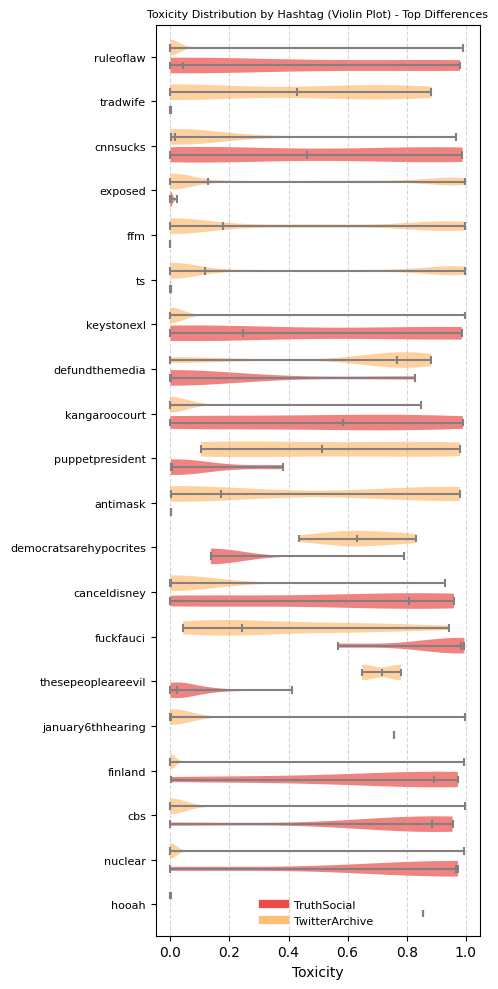

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

MIN_COUNT = 5
top_n = 20

# Find common hashtags
common_hashtags = set(summary_hashtag_toxicity_truthSocial) & set(summary_hashtag_toxicity_twitterArchive)

# Compute difference based on mean
hashtag_diffs = []
for h in common_hashtags:
    d1 = summary_hashtag_toxicity_truthSocial[h]
    d2 = summary_hashtag_toxicity_twitterArchive[h]
    if d1["count"] >= MIN_COUNT and d2["count"] >= MIN_COUNT:
        diff = abs(d1["mean"] - d2["mean"])
        hashtag_diffs.append((h, diff))

# Sort and pick top N
top_diff_hashtags = sorted(hashtag_diffs, key=lambda x: x[1], reverse=True)[:top_n]
hashtags = [h[0] for h in top_diff_hashtags]

# Prepare data for violin plot
truth_data = [summary_hashtag_toxicity_truthSocial[h]["scores"] for h in hashtags]
twitter_data = [summary_hashtag_toxicity_twitterArchive[h]["scores"] for h in hashtags]

# Create violin plot
fig, ax = plt.subplots(figsize=(5, 10))

positions_truth = np.arange(len(hashtags)) * 2.0
positions_twitter = positions_truth + 0.8

vp1 = ax.violinplot(truth_data, positions=positions_truth, widths=0.7, showmeans=False, showextrema=True, showmedians=True, vert=False)
vp2 = ax.violinplot(twitter_data, positions=positions_twitter, widths=0.7, showmeans=False, showextrema=True, showmedians=True, vert=False)

# for i, (truth, twitter) in enumerate(zip(truth_data, twitter_data)):
#     ax.plot(np.mean(truth), positions_truth[i], 'o', color='#eb4d4b', markersize=2)
#     ax.plot(np.mean(twitter), positions_twitter[i] , 'o', color='#ffbe76', markersize=2)

# Coloring
for vp in vp1['bodies']:
    vp.set_facecolor('#eb4d4b')
    vp.set_alpha(0.7)

for vp in vp2['bodies']:
    vp.set_facecolor('#ffbe76')
    vp.set_alpha(0.7)

for key in ['cmedians', 'cmins', 'cmaxes', 'cbars', 'cmeans']:
    if key in vp1:
        vp1[key].set_color("#858080")
        vp1[key].set_linewidth(1.5)

for key in ['cmedians', 'cmins', 'cmaxes', 'cbars', 'cmeans']:
    if key in vp2:
        vp2[key].set_color("#858080")
        vp2[key].set_linewidth(1.5)

# Axes and labels
xticks = positions_truth + 0.4
ax.set_yticks(xticks)
ax.set_yticklabels(hashtags, rotation=0, fontsize=8)
ax.set_ylim([-1, max(positions_twitter) + 1])
ax.set_xlabel("Toxicity")
ax.set_title("Toxicity Distribution by Hashtag (Violin Plot) - Top Differences", fontsize=8)

# Add legend manually
ax.plot([], [], color='#eb4d4b', label='TruthSocial', lw=6)
ax.plot([], [], color='#ffbe76', label='TwitterArchive', lw=6)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)

ax.legend(frameon=False, fontsize=8, loc='best')
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text


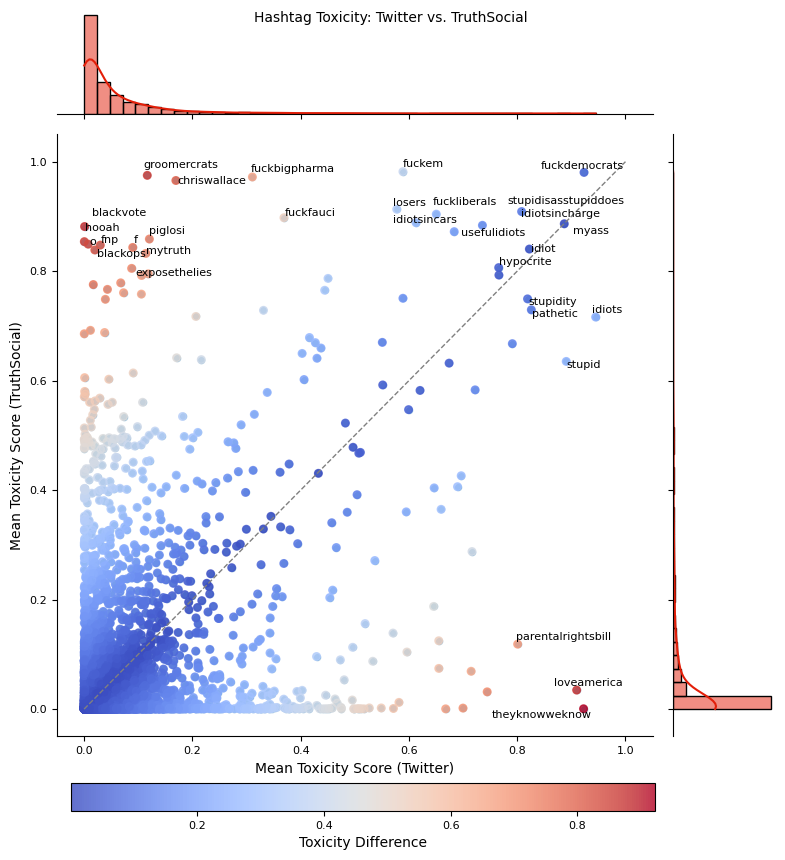

In [ ]:
MIN_COUNT = 2
THRESHOLD = 0.8
points = []
for h in set(summary_hashtag_toxicity_twitterArchive) & set(summary_hashtag_toxicity_truthSocial):
    d_tw = summary_hashtag_toxicity_twitterArchive[h]
    d_tr = summary_hashtag_toxicity_truthSocial[h]
    if d_tw['count'] >= MIN_COUNT and d_tr['count'] >= MIN_COUNT:
        # Only include hashtags with sufficient data
        points.append((d_tw['mean'], d_tr['mean'], h))

# Unpack for plotting
x = [pt[0] for pt in points]  # Twitter
y = [pt[1] for pt in points]  # TruthSocial
labels = [pt[2] for pt in points]


# Data
df = pd.DataFrame({'Twitter': x, 'TruthSocial': y})
df["Difference"] = np.abs(df["Twitter"] - df["TruthSocial"])

# Joint plot setup and kde on marginal distributions
 
grid = sns.jointplot(data=df, 
                  x="Twitter",
                  y="TruthSocial", 
                  kind="scatter", 
                  alpha=0.6, 
                  height=8, 
                  marginal_kws=dict(bins=40, fill=True, kde=True,color="#e31f09", line_kws={"color": "#c0392b"}), 
                  s=30, )


 
 
# Use ax_joint for scatter with color
points = grid.ax_joint.scatter(
    df["Twitter"], df["TruthSocial"],
    c=df["Difference"], cmap="coolwarm", s=30, alpha=0.8
)

# Colorbar at bottom
cbar_ax = grid.fig.add_axes([0.1, -0.02, 0.73, 0.035])  # [left, bottom, width, height]
cbar = grid.fig.colorbar(points, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Toxicity Difference", fontsize=10)
cbar.ax.tick_params(labelsize=8)

# # Annotate outliers on ax_joint
texts = []
for xi, yi, label in zip(x, y, labels):
    if xi > THRESHOLD or yi > THRESHOLD:
        # g.ax_joint.annotate(label, (xi+0.01, yi+0.01), fontsize=6,)
        texts.append(grid.ax_joint.text(xi, yi, label, fontsize=8))

adjust_text(texts, ax=grid.ax_joint, 
            # arrowprops=dict(arrowstyle="-", color='gray', lw=0.5)
            )
 
# set ticks size as 8
grid.ax_joint.tick_params(axis='both', which='major', labelsize=8)


# add 0.5 to the diagonal line for better visibility
grid.ax_joint.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)

# Labels
grid.set_axis_labels("Mean Toxicity Score (Twitter)", "Mean Toxicity Score (TruthSocial)", fontsize=10)
grid.fig.suptitle(f"Hashtag Toxicity: Twitter vs. TruthSocial", fontsize=10)
# save figure

plt.savefig("hashtag_toxicity_comparison.pdf", dpi=300, bbox_inches='tight')

# Domain Analysis

In [ ]:
import tldextract
from urlextract import URLExtract

extractor = URLExtract()
example_text = "Text with URLs. Let's have URL janlipovsky.cz as an example. 'http://forums.news.cnn.com/"

for url in extractor.gen_urls(example_text):
    print(url)
    extraction_reesult = tldextract.extract(url)
    print(extraction_reesult)   
    print("Domain:", extraction_reesult.domain)  
    print("====================================")

janlipovsky.cz
ExtractResult(subdomain='', domain='janlipovsky', suffix='cz', is_private=False)
Domain: janlipovsky
http://forums.news.cnn.com/
ExtractResult(subdomain='forums.news', domain='cnn', suffix='com', is_private=False)
Domain: cnn


In [ ]:
import duckdb


file_pattern = "/chistera/CaseStudyOutputs/HashtagDodetoxify_outputs/ArchiverTwitterV1/*.jsonl"
query = f"""
    SELECT post_id FROM read_json_auto('{file_pattern}')
    WHERE CAST(json_extract(body, '$.toxicity') AS DOUBLE) > 0.5
"""

df = duckdb.sql(query).fetchall()
results = duckdb.sql(query).fetchall() 
results = [r[0] for r in results]

print(f"Number of toxic posts: {len(results)}")

# Save to file
with open("twitter_archive_toxic_post_ids.txt", "w") as f:
    for post_id in results:
        f.write(f"{post_id}\n")

Number of toxic posts: 21615352


In [ ]:
import duckdb


file_pattern = "/chistera/CaseStudyOutputs/HashtagDodetoxify_outputs/TruthSocial/*.jsonl"
query = f"""
    SELECT post_id FROM read_json_auto('{file_pattern}')
    WHERE CAST(json_extract(body, '$.toxicity') AS DOUBLE) > 0.5
"""

df = duckdb.sql(query).fetchall()
results = duckdb.sql(query).fetchall() 
results = [r[0] for r in results]

print(f"Number of toxic posts: {len(results)}")

# Save to file
with open("truthsocial_archive_toxic_post_ids.txt", "w") as f:
    for post_id in results:
        f.write(f"{post_id}\n")

Number of toxic posts: 62819


In [ ]:
import duckdb 
import tldextract
from urlextract import URLExtract
from more_itertools import chunked
import math
from tqdm import tqdm
from collections import Counter
import json


truthSocial_toxic_post_ids_path = "truthsocial_toxic_post_ids.txt"
with open(truthSocial_toxic_post_ids_path, "r") as f:
    toxic_post_ids = set(f.read().splitlines())


entity_df = cursor_truthsocial.execute(
    f"""SELECT post_id, entity_type, body
        FROM entities
        WHERE entity_type = 'LINK' 
    """).df()

entity_df = entity_df[entity_df["post_id"].isin(toxic_post_ids)]

print(entity_df)

truthSocial_domains_count = Counter()
extractor = URLExtract()



for body in entity_df["body"]:
    for url in extractor.gen_urls(body):
        # print("====================================")
        # print(f"URL: {url}")
        extraction_result = tldextract.extract(url)
        # print("Domain:", extraction_result.domain)
        # print("====================================")
        extraction_text = f"{extraction_result.domain}.{extraction_result.suffix}"
        truthSocial_domains_count[extraction_text] += 1

    

with open("truthsocial_domains_count.json", "w") as f:
    json.dump(truthSocial_domains_count, f, indent=4)

In [ ]:
twitter_toxic_post_ids_path = "twitter_archive_toxic_post_ids.txt"
with open(truthSocial_toxic_post_ids_path, "r") as f:
    toxic_post_ids = set(f.read().splitlines())


entity_df = cursor_twitter.execute(
    f"""SELECT post_id, entity_type, body
        FROM entities
        WHERE entity_type = 'LINK' 
    """).df()

entity_df = entity_df[entity_df["post_id"].isin(toxic_post_ids)]

print(entity_df)

truthSocial_domains_count = Counter()
extractor = URLExtract()



for body in entity_df["body"]:
    for url in extractor.gen_urls(body):
        # print("====================================")
        # print(f"URL: {url}")
        extraction_result = tldextract.extract(url)
        # print("Domain:", extraction_result.domain)
        # print("====================================")
        extraction_text = f"{extraction_result.domain}.{extraction_result.suffix}"
        truthSocial_domains_count[extraction_text] += 1

    

with open("twitter_archive_domains_count.json", "w") as f:
    json.dump(truthSocial_domains_count, f, indent=4)

In [ ]:
import json
# loading domain counts from the file
with open("twitter_archive_domains_count.json", "r") as f:
    twitter_archive_domains_count = json.load(f)

with open("truthsocial_domains_count.json", "r") as f:
    truthsocial_domains_count = json.load(f)

In [ ]:
from collections import defaultdict

sorted_domains_by_frequency_twitter = sorted(twitter_archive_domains_count.items(), key=lambda x: x[1], reverse=True)
sorted_domains_by_frequency_truthsocial = sorted(truthsocial_domains_count.items(), key=lambda x: x[1], reverse=True)


domain_ranks = defaultdict(lambda: dict())
for rank, (domain, count) in enumerate(truthsocial_domains_count.items()):
    domain_ranks[domain]["TruthSocial"] = rank+1

    if domain not in twitter_archive_domains_count:
        domain_ranks[domain]["TwitterArchive"] = None

for rank, (domain, count) in enumerate(twitter_archive_domains_count.items()):
    domain_ranks[domain]["TwitterArchive"] = rank+1
    if domain not in truthsocial_domains_count:
        domain_ranks[domain]["TruthSocial"] = None


In [ ]:
domain_ranks

defaultdict(<function __main__.<lambda>()>,
            {'nypost.com': {'TruthSocial': 1, 'TwitterArchive': 287},
             'forbes.com': {'TruthSocial': 2, 'TwitterArchive': 289},
             'youtube.com': {'TruthSocial': 3, 'TwitterArchive': 113},
             'youtu.be': {'TruthSocial': 4, 'TwitterArchive': 41},
             'thedcpatriot.com': {'TruthSocial': 5, 'TwitterArchive': 5296},
             'fearandblood.com': {'TruthSocial': 6, 'TwitterArchive': 11517},
             'rairfoundation.com': {'TruthSocial': 7, 'TwitterArchive': 2867},
             'thegatewaypundit.com': {'TruthSocial': 8, 'TwitterArchive': 294},
             'bitchute.com': {'TruthSocial': 9, 'TwitterArchive': 648},
             'rt.com': {'TruthSocial': 10, 'TwitterArchive': 588},
             'rumble.com': {'TruthSocial': 11, 'TwitterArchive': 687},
             'truthsocial.com': {'TruthSocial': 12, 'TwitterArchive': 5276},
             'tiktok.com': {'TruthSocial': 13, 'TwitterArchive': 89},
       

In [ ]:
import pandas as pd
path = "partisan_bias_scores.csv"
partisan_bias_df = pd.read_csv(path)
partisan_bias_df.head()

,domain,fb_score,mturk_score,allsides_score,allsides_score_community,mbfc_score,media_score,buntain_share_ideology_score
0,100fedup.com,NaN,NaN,NaN,NaN,NaN,NaN,1.551377
1,100milefreepress.net,NaN,NaN,NaN,NaN,-0.33,NaN,NaN
2,100percentfedup.com,0.856,NaN,NaN,NaN,1.00,NaN,1.517266
3,1011now.com,NaN,NaN,NaN,NaN,0.00,NaN,0.263504
4,10best.com,NaN,NaN,NaN,NaN,NaN,NaN,0.088507


In [ ]:
domain2_mbfc_score = defaultdict()
for _, row in partisan_bias_df.iterrows():
    domain = row["domain"].lower()
    mbfc_score = row["mbfc_score"]
    if domain in domain_ranks and pd.notna(mbfc_score):
        domain2_mbfc_score[domain] = mbfc_score

In [ ]:
len(domain2_mbfc_score)

1394

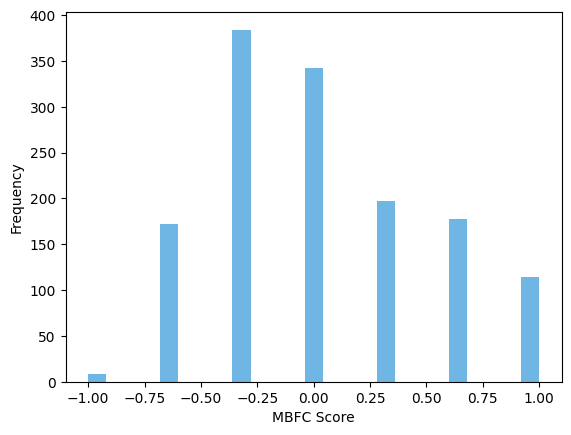

In [ ]:
import matplotlib.pyplot as plt

plt.hist(domain2_mbfc_score.values(), bins=25, color="#3498db", alpha=0.7)

plt.xlabel("MBFC Score")
plt.ylabel("Frequency")
plt.show()

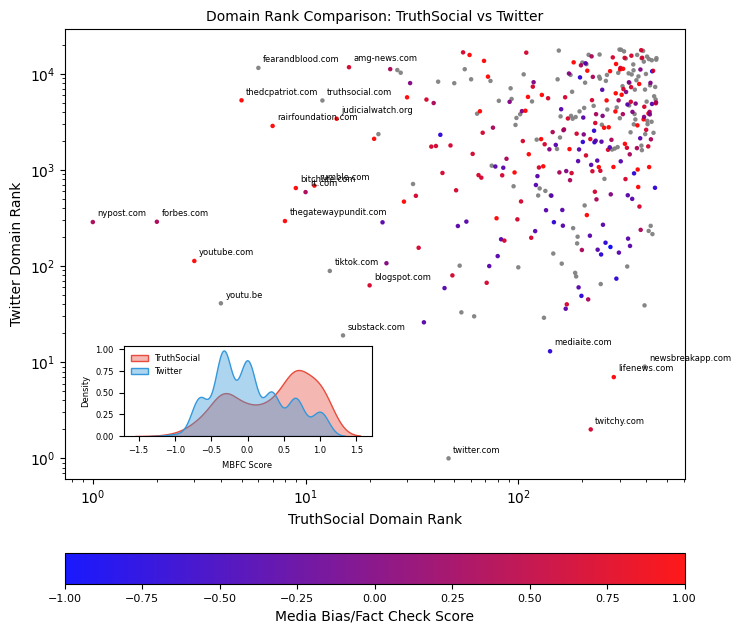

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import matplotlib.colors as mcolors


import numpy as np
fig, ax = plt.subplots(figsize=(8, 8))

# Extract data for plotting
domains = list(domain_ranks.keys())
truthsocial_ranks = [domain_ranks[domain].get("TruthSocial", None) for domain in domains]
twitter_ranks = [domain_ranks[domain].get("TwitterArchive", None) for domain in domains]
scores = [domain2_mbfc_score.get(domain, None) for domain in domains]

nan_indices = [i for i, score in enumerate(scores) if score is None]

clean_truthsocial_ranks = [rank for i, rank in enumerate(truthsocial_ranks) if i not in nan_indices]
clean_twitter_ranks = [rank for i, rank in enumerate(twitter_ranks) if i not in nan_indices]
clean_scores = [score for i, score in enumerate(scores) if i  not in nan_indices]

truth_social_max = max(filter(lambda x: x is not None, truthsocial_ranks), default=0)
twitter_max = max(filter(lambda x: x is not None, twitter_ranks), default=0)

cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["blue", "purple", "red"])
 

size_by_frequency = np.ones(len(clean_truthsocial_ranks)) * 5  # Default size


scatter = ax.scatter(clean_truthsocial_ranks , clean_twitter_ranks , alpha=0.9, c=clean_scores,  cmap=cmap, s=size_by_frequency,zorder=2)
cbar = plt.colorbar(scatter, ax=ax,orientation='horizontal', pad=0.12, 
                    # aspect=50
                    )  # Adjusted pad and aspect for better appearance
            # orientation='horizontal', pad=0.1, aspect=80,
             
cbar.ax.tick_params(labelsize=8)

cbar.set_label('Media Bias/Fact Check Score', fontsize=10)

# plot no score points in gray
no_score_indices = [i for i, score in enumerate(scores) if score is None]
no_score_truthsocial_ranks = [truthsocial_ranks[i] for i in no_score_indices]
no_score_twitter_ranks = [twitter_ranks[i] for i in no_score_indices]
size_by_frequency_no_score = np.ones(len(no_score_truthsocial_ranks)) * 5  # Smaller size for no score points
ax.scatter(no_score_truthsocial_ranks, no_score_twitter_ranks, color='gray', alpha=0.9, s=size_by_frequency_no_score, zorder=1)
 

# ax.plot([0, truth_social_max], [0, twitter_max], color='gray', linestyle='--', linewidth=1)

ax.set_xlabel("TruthSocial Domain Rank", fontsize=10)
ax.set_ylabel("Twitter Domain Rank", fontsize=10)
ax.set_title("Domain Rank Comparison: TruthSocial vs Twitter", fontsize=10)      

# set ticks size as 8
ax.tick_params(axis='both', which='major', labelsize=10)

# ax.loglog(True)

# annotate points top ranks for both platforms and bottom ranks
# for domain in domains:  
#     ts_rank = domain_ranks[domain].get("TruthSocial", None)
#     tw_rank = domain_ranks[domain].get("TwitterArchive", None)
    
#     if ts_rank is not None and tw_rank is not None:
#         if ts_rank <= 10 or tw_rank <= 10 :
#             ax.annotate(domain, (ts_rank, tw_rank), fontsize=7, alpha=0.7)

# Annotate outliers on ax_joint
texts = []
for xi, yi, label in zip(truthsocial_ranks, twitter_ranks, domains):
    if xi is not None and yi is not None:
        if xi <= 20 or yi <= 20:
            texts.append(
                ax.text(xi * 1.05, yi * 1.1, label, fontsize=6, ha='left', va='bottom',clip_on=False)
                )
 

# adjust_text(
#     texts,
#     ax=ax,
#     only_move='text',         # Don't touch data points
#     expand_text=(1.05, 1.05), # Mild adjustment
#     lim=20                    # Limit the number of iterations (default is 500)
# )

ax.set_xscale('log')
ax.set_yscale('log')



# inset axis for media bias fact check distrubution
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
inset_ax = inset_axes(ax, 
                      width="40%", 
                      height="20%", 
                      loc='lower left', 
                      bbox_to_anchor=(0.095, 0.095, 1, 1), # posx, posy, width, height 
                      borderpad=0, 
                      bbox_transform=ax.transAxes)


import seaborn as sns
import pandas as pd
from scipy.stats import mannwhitneyu

domain_ranks_df = pd.DataFrame.from_dict(domain_ranks, orient='index')
domain_ranks_df.reset_index(inplace=True)
domain_ranks_df.rename(columns={'index': 'domain'}, inplace=True)
domain_ranks_df['mbfc_score'] = domain_ranks_df['domain'].map(lambda x: domain2_mbfc_score.get(x), None)
domain_ranks_df = domain_ranks_df[domain_ranks_df['mbfc_score'].notna()]
domain_ranks_df.sort_values(by='mbfc_score', ascending=False, inplace=True)


truthSocial_mbfcc_scores = domain_ranks_df['mbfc_score'][domain_ranks_df['TruthSocial'].notna()]
twitterArchive_mbfcc_scores = domain_ranks_df['mbfc_score'][domain_ranks_df['TwitterArchive'].notna()]

# kde plot of the scores
sns.kdeplot(truthSocial_mbfcc_scores, ax=inset_ax, fill=True, color='#e74c3c', label="TruthSocial", alpha=0.4, linewidth=1)
sns.kdeplot(twitterArchive_mbfcc_scores, ax=inset_ax, fill=True, color='#3498db', label="Twitter", alpha=0.4, linewidth=1)

# inset axis ticks font size
inset_ax.tick_params(axis='both', which='major', labelsize=6)
inset_ax.set_xlabel("MBFC Score", fontsize=6)
inset_ax.set_ylabel("Density", fontsize=6)
inset_ax.legend(frameon=False, fontsize=6)


# xmin, xmax = ax.get_xlim()
# ax.set_xlim(xmin, xmax * 2.1)  # Increase upper limit by 10%
# plt.tight_layout()
plt.savefig("domain_rank_comparison_truthsocial_twitter_archive.pdf", dpi=300 )
plt.show()

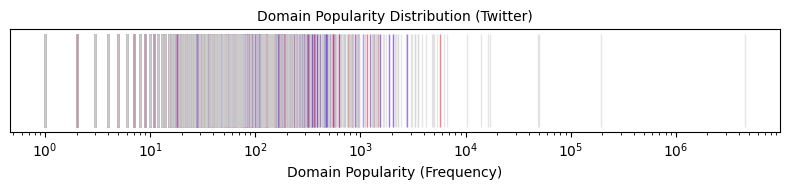

In [ ]:
import seaborn as sns
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(8, 2))

cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["blue", "purple", "red"])

domains = [domain for domain, count in twitter_archive_domains_count.items() if count > 0]
domain_popularities = [count for domain, count in twitter_archive_domains_count.items()]
colors = [domain2_mbfc_score.get(domain, None) for domain in domains]


min = np.min([c for c in colors if c])
max = np.max([c for c in colors if c])
norm = mcolors.Normalize(vmin=min, vmax=max)
line_colors = [
    cmap(norm(s)) if s is not None else (0.8, 0.8, 0.8, 0.4)   # light grey for missing
    for s in colors
]


ax.vlines(domain_popularities, 0, 1, colors=line_colors,  cmap=cmap, alpha=0.5, linewidth=1)
ax.set_xlabel("Domain Popularity (Frequency)", fontsize=10)
ax.set_title("Domain Popularity Distribution (Twitter)", fontsize=10)
# set x axis log scale
ax.set_xscale('log')
ax.set_yticks([])  # Hide y-axis ticks
# ax.set_xlim(0, max(domain_popularities) * 1.1)
plt.tight_layout()




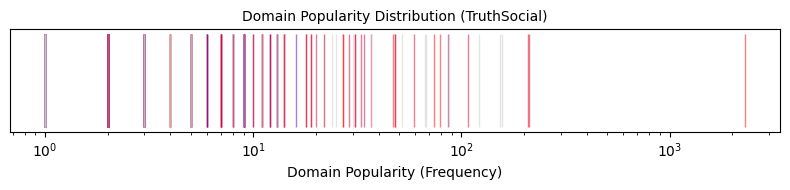

In [ ]:
import seaborn as sns
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(8, 2))

cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["blue", "purple", "red"])

domains = [domain for domain, count in truthsocial_domains_count.items() if count > 0]
domain_popularities = [count for domain, count in truthsocial_domains_count.items()]
colors = [domain2_mbfc_score.get(domain, None) for domain in domains]


min = np.min([c for c in colors if c])
max = np.max([c for c in colors if c])
norm = mcolors.Normalize(vmin=min, vmax=max)
line_colors = [
    cmap(norm(s)) if s is not None else (0.8, 0.8, 0.8, 0.4)   # light grey for missing
    for s in colors
]


ax.vlines(domain_popularities, 0, 1, colors=line_colors,  cmap=cmap, alpha=0.5, linewidth=1)
ax.set_xlabel("Domain Popularity (Frequency)", fontsize=10)
ax.set_title("Domain Popularity Distribution (TruthSocial)", fontsize=10)
# set x axis log scale
ax.set_xscale('log')
ax.set_yticks([])  # Hide y-axis ticks
# ax.set_xlim(0, max(domain_popularities) * 1.1)
plt.tight_layout()




In [ ]:
# get color of 0.3 from cmap
norm = mcolors.Normalize(vmin=0, vmax=1)
cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["blue", "purple", "red"])
color = cmap(norm(0.3))
print(f"Color for 0.3: {color}")


Color for 0.3: (np.float64(0.29920799692425987), np.float64(0.0), np.float64(0.7031295655517109), np.float64(1.0))


In [ ]:
domain_ranks

defaultdict(<function __main__.<lambda>()>,
            {'nypost.com': {'TruthSocial': 1, 'TwitterArchive': 287},
             'forbes.com': {'TruthSocial': 2, 'TwitterArchive': 289},
             'youtube.com': {'TruthSocial': 3, 'TwitterArchive': 113},
             'youtu.be': {'TruthSocial': 4, 'TwitterArchive': 41},
             'thedcpatriot.com': {'TruthSocial': 5, 'TwitterArchive': 5296},
             'fearandblood.com': {'TruthSocial': 6, 'TwitterArchive': 11517},
             'rairfoundation.com': {'TruthSocial': 7, 'TwitterArchive': 2867},
             'thegatewaypundit.com': {'TruthSocial': 8, 'TwitterArchive': 294},
             'bitchute.com': {'TruthSocial': 9, 'TwitterArchive': 648},
             'rt.com': {'TruthSocial': 10, 'TwitterArchive': 588},
             'rumble.com': {'TruthSocial': 11, 'TwitterArchive': 687},
             'truthsocial.com': {'TruthSocial': 12, 'TwitterArchive': 5276},
             'tiktok.com': {'TruthSocial': 13, 'TwitterArchive': 89},
       

In [ ]:
domain_ranks_df = pd.DataFrame.from_dict(domain_ranks, orient='index')
domain_ranks_df.reset_index(inplace=True)
domain_ranks_df.rename(columns={'index': 'domain'}, inplace=True)
domain_ranks_df['mbfc_score'] = domain_ranks_df['domain'].map(lambda x: domain2_mbfc_score.get(x), None)
domain_ranks_df = domain_ranks_df[domain_ranks_df['mbfc_score'].notna()]
domain_ranks_df.sort_values(by='mbfc_score', ascending=False, inplace=True)
 
# Create a DataFrame for plotting
domain_df = pd.DataFrame({
    'Domain': domain_ranks_df['domain'],
    'TruthSocial Rank': domain_ranks_df['TruthSocial'],
    'Twitter Archive Rank': domain_ranks_df['TwitterArchive'],
    'MBFC Score': domain_ranks_df['mbfc_score']
})  

domain_df["is_right_leaning"] = domain_df["MBFC Score"].apply(lambda x: x > 0)

domain_df

,Domain,TruthSocial Rank,Twitter Archive Rank,MBFC Score,is_right_leaning
78,bongino.com,79.0,314.0,1.0,True
6844,vdare.com,NaN,6646.0,1.0,True
6965,headlineusa.com,NaN,6767.0,1.0,True
12254,newswithviews.com,NaN,12109.0,1.0,True
29,thebeltwayreport.com,30.0,5690.0,1.0,True
...,...,...,...,...,...
1379,libcom.org,NaN,1043.0,-1.0,False
11823,nationalzero.com,NaN,11677.0,-1.0,False
4730,deepleftfield.info,NaN,4500.0,-1.0,False
270,bipartisanreport.com,271.0,158.0,-1.0,False


In [ ]:
from scipy.stats import mannwhitneyu


domain_df_filtered = domain_df.dropna(subset=["TruthSocial Rank", "Twitter Archive Rank"]).copy()
domain_df_filtered.loc[:, "Relative Popularity"] = domain_df_filtered["Twitter Archive Rank"] - domain_df_filtered["TruthSocial Rank"]
right = domain_df_filtered[domain_df_filtered["is_right_leaning"] == True]["Relative Popularity"]
left = domain_df_filtered[domain_df_filtered["is_right_leaning"] == False]["Relative Popularity"]


stat, p = mannwhitneyu(right, left, alternative='greater')  # test if right > left
print("Mann-Whitney U test p-value:", p)
print("U statistic:", stat)


print("Median difference (right):", right.median())
print("Median difference (left):", left.median())


print("This means:")
if p < 0.05:
    print("Right-leaning domains are statistically significantly more popular on TruthSocial than on Twitter.")
else:
    print("No statistically significant difference in popularity between right-leaning and left-leaning domains on TruthSocial and Twitter.")

Mann-Whitney U test p-value: 0.0003342224099961965
U statistic: 6644.0
Median difference (right): 1964.0
Median difference (left): 947.5
This means:
Right-leaning domains are statistically significantly more popular on TruthSocial than on Twitter.


In [ ]:
print("# if Right-leaning domains:", len(right))
print("# if Left-leaning domains:", len(left))

# if Right-leaning domains: 133
# if Left-leaning domains: 78


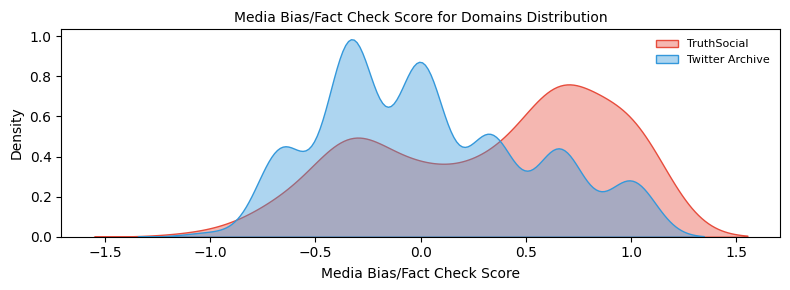

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import mannwhitneyu

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3))

domain_ranks_df = pd.DataFrame.from_dict(domain_ranks, orient='index')
domain_ranks_df.reset_index(inplace=True)
domain_ranks_df.rename(columns={'index': 'domain'}, inplace=True)
domain_ranks_df['mbfc_score'] = domain_ranks_df['domain'].map(lambda x: domain2_mbfc_score.get(x), None)
domain_ranks_df = domain_ranks_df[domain_ranks_df['mbfc_score'].notna()]
domain_ranks_df.sort_values(by='mbfc_score', ascending=False, inplace=True)


truthSocial_mbfcc_scores = domain_ranks_df['mbfc_score'][domain_ranks_df['TruthSocial'].notna()]
twitterArchive_mbfcc_scores = domain_ranks_df['mbfc_score'][domain_ranks_df['TwitterArchive'].notna()]

# kde plot of the scores
sns.kdeplot(truthSocial_mbfcc_scores, ax=ax, fill=True, color='#e74c3c', label="TruthSocial", alpha=0.4, linewidth=1)
sns.kdeplot(twitterArchive_mbfcc_scores, ax=ax, fill=True, color='#3498db', label="Twitter Archive", alpha=0.4, linewidth=1)


ax.set_xlabel("Media Bias/Fact Check Score", fontsize=10)

# ticks size
ax.tick_params(axis='both', which='major', labelsize=10)

ax.legend(frameon=False, fontsize=8)

ax.set_title("Media Bias/Fact Check Score for Domains Distribution", fontsize=10)

plt.tight_layout()
plt.savefig("media_bias_fact_check_score_distribution.pdf", dpi=300, bbox_inches='tight')
plt.show()